In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[0]  # remonte de notebooks -> racine projet
sys.path.append(str(PROJECT_ROOT))

print("Project root added to PYTHONPATH:", PROJECT_ROOT)

Project root added to PYTHONPATH: /home/aurelien/formation_openclassrooms/projet_8/cityseg-project


In [8]:
from src.data.cityscapes_labels import ID2GROUP, MAX_LABEL_ID, GROUPS
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import random

from src.data.cityscapes_mapping import map_mask_to_groups
from src.data.cityscapes_labels import GROUPS


In [9]:

print("MAX_LABEL_ID:", MAX_LABEL_ID)
print("Some mappings:", {k: ID2GROUP[k] for k in range(0, 34) if k in ID2GROUP})

MAX_LABEL_ID: 33
Some mappings: {0: 'void', 1: 'void', 2: 'void', 3: 'void', 4: 'void', 5: 'void', 6: 'void', 7: 'flat', 8: 'flat', 9: 'flat', 10: 'flat', 11: 'construction', 12: 'construction', 13: 'construction', 14: 'construction', 15: 'construction', 16: 'construction', 17: 'object', 18: 'object', 19: 'object', 20: 'object', 21: 'nature', 22: 'nature', 23: 'sky', 24: 'human', 25: 'human', 26: 'vehicle', 27: 'vehicle', 28: 'vehicle', 29: 'vehicle', 30: 'vehicle', 31: 'vehicle', 32: 'vehicle', 33: 'vehicle'}


In [ ]:
df = pd.read_csv(f"{PROJECT_ROOT}/data/manifests/cityscapes_pairs.csv")
ROOT = Path(f"{PROJECT_ROOT}/data")

# scan rapide sur 200 masks
N = min(200, len(df))
mins, maxs = [], []
unknown_count = 0

for i in range(N):
    m = np.array(Image.open(ROOT / df.loc[i, "mask_path"]))
    mins.append(int(m.min()))
    maxs.append(int(m.max()))
    unknown_count += int(np.sum(m > 33))

print("min over dataset sample:", min(mins))
print("max over dataset sample:", max(maxs))
print("pixels with id > 33 (should be 0):", unknown_count)

min over dataset sample: 0
max over dataset sample: 33
pixels with id > 33 (should be 0): 0


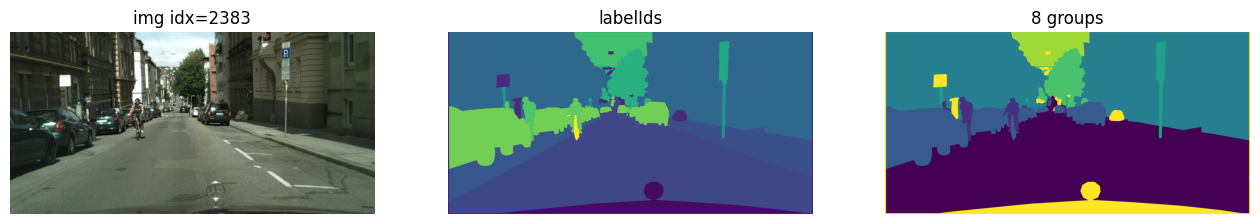

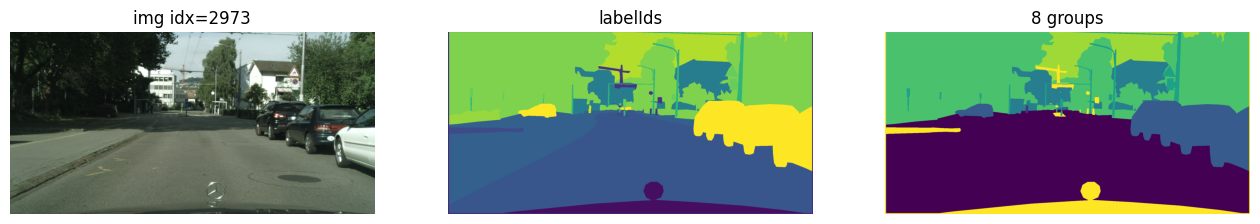

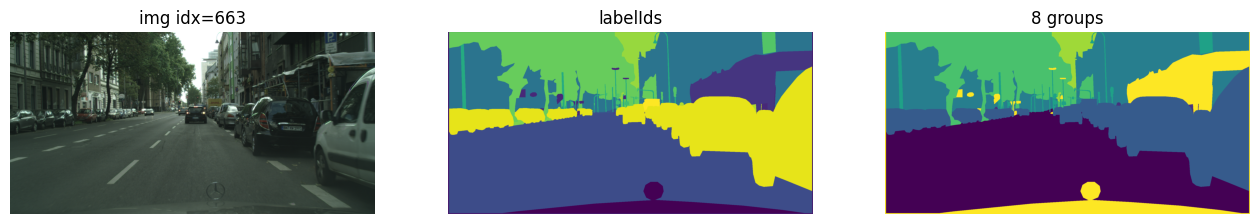

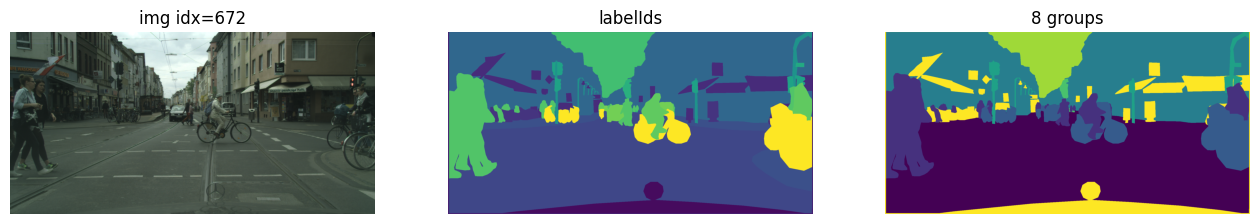

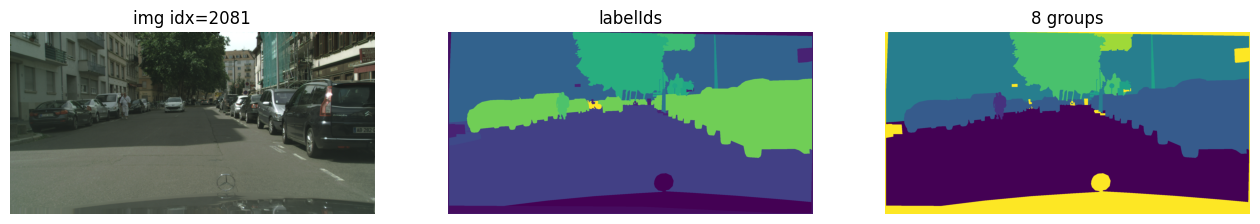

In [12]:

for _ in range(5):
    idx = random.randint(0, len(df)-1)
    row = df.iloc[idx]
    img = np.array(Image.open(ROOT / row["image_path"]).convert("RGB"))
    mask = np.array(Image.open(ROOT / row["mask_path"]))
    mapped = map_mask_to_groups(mask)

    plt.figure(figsize=(16,5))
    plt.subplot(1,3,1); plt.imshow(img); plt.title(f"img idx={idx}"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask); plt.title("labelIds"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(mapped, vmin=0, vmax=len(GROUPS)-1); plt.title("8 groups"); plt.axis("off")
    plt.show()

In [14]:
u = np.unique(mask)
ug = np.unique(mapped)
print("labelIds uniques:", u)
print("groupIds uniques:", ug)
print("group names:", [GROUPS[i] for i in ug])

labelIds uniques: [ 1  2  3  4  7  8 11 13 17 20 21 23 24 26 33]
groupIds uniques: [0 1 2 3 4 5 6 7]
group names: ['flat', 'human', 'vehicle', 'construction', 'object', 'nature', 'sky', 'void']


In [13]:
N = 200
unknown = 0
for i in range(N):
    m = np.array(Image.open(ROOT / df.loc[i, "mask_path"]))
    unknown += int((m > 33).sum())
print("pixels id>33:", unknown)

pixels id>33: 0
